In [ ]:
# Import pustaka yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [2]:
# Load dataset
df = pd.read_csv("student_habits_performance.csv")

In [10]:
# Identifikasi kolom kategori yang perlu dikonversi
categorical_columns = ['diet_quality', 'exercise_frequency', 'internet_quality', 'gender']

In [11]:
# Konversi kategori ke numerik menggunakan LabelEncoder
encoder = LabelEncoder()
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

In [12]:
# Pilih fitur numerik yang akan digunakan dalam model
features = ['study_hours_per_day', 'attendance_percentage', 'diet_quality', 'exercise_frequency', 'internet_quality']
X = df[features]
y = df['exam_score']

In [13]:
# Menangani missing values (jika ada)
X.fillna(X.mean(), inplace=True)
y.fillna(y.mean(), inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_22388\586158372.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.mean(), inplace=True)


In [14]:
# Pisahkan data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Inisialisasi dan latih model Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Prediksi pada data uji
y_pred = model.predict(X_test)

In [18]:
# Evaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error (MSE): 67.89
R² Score: 0.74


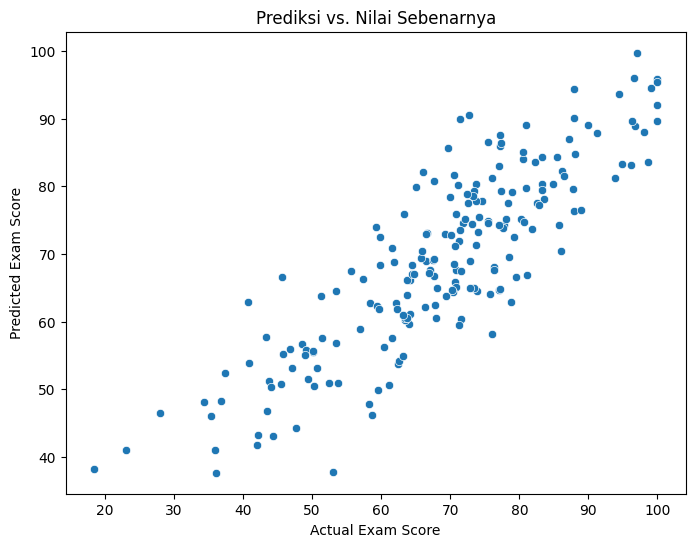

In [19]:
# Visualisasi hasil prediksi vs nilai asli
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Prediksi vs. Nilai Sebenarnya")
plt.show()


In [20]:
# Menampilkan koefisien dari model
coefficients = pd.DataFrame(model.coef_, index=features, columns=["Coefficient"])
print("\nKoefisien Model Linear Regression:")
print(coefficients)



Koefisien Model Linear Regression:
                       Coefficient
study_hours_per_day       9.517969
attendance_percentage     0.151615
diet_quality             -0.031145
exercise_frequency        1.341624
internet_quality         -0.118767


In [27]:
# Data baru untuk prediksi
new_data = pd.DataFrame({
    'study_hours_per_day': [9.0],
    'attendance_percentage': [90.0],
    'diet_quality': [1],   # (Tergantung hasil encoding)
    'exercise_frequency': [3],
    'internet_quality': [9]
})

# Prediksi nilai ujian
predicted_score = model.predict(new_data)
print(f"Prediksi Exam Score untuk siswa ini: {predicted_score[0]:.2f}")


Prediksi Exam Score untuk siswa ini: 121.42
